# Grid Search Post-Evaluation: VAE vs TimeGAN (IMU+Radar)

Evaluate **4 synthetic datasets** (2 generation methods × 2 hyperparameter settings) produced from the
QUIDA multimodal fall-detection data using the **IMU+Radar** sensor configuration, and produce a
**scientifically defensible ranking** to determine which hyperparameter setting yields better-quality
synthetic data.

**Generation methods:** VAE, TimeGAN
**Hyperparameter settings:** Default (same_params), Optimised (best_params)
**Sensor configuration:** IMU+Radar (fixed — chosen from prior experiment)

**Structure:**

* **Part 1 — Within-model comparison**: Does grid-search optimisation improve each model?
  - VAE default vs VAE optimised
  - TimeGAN default vs TimeGAN optimised
* **Part 2 — Cross-model comparison**: Which of the 4 datasets is best overall?
* **Part 3 — Final recommendation**: Combined quality+quantity ranking.

**Evaluation dimensions (grouped to avoid double-counting correlated metrics):**

* *Fidelity* — MMD (RBF), Wasserstein, multivariate Hellinger, correlation/dependency preservation.
* *Diversity / coverage* — coverage, density, nearest-neighbour diversity, variance preservation.

Scores are built hierarchically (sub-group → category → overall) so no dimension dominates merely by
containing more metrics.

---
### Methodological reference

El Emam K, Mosquera L, Fang X, El-Hussuna A. *Utility Metrics for Evaluating Synthetic Health Data
Generation Methods: Validation Study.* JMIR Med Inform. 2022;10(4):e35734.
[doi:10.2196/35734](https://doi.org/10.2196/35734)

> **Honest limitation.** The real reference sets here are small (~99 samples). With few real samples and
> high feature dimensionality (~1137 features), every metric is an *approximation*. This notebook is
> built to be explicit about representation choices and to flag statistical instability rather than hide it.

## 1. Configuration

All tunable parameters live here. The sensor configuration is fixed to **IMU+Radar** — the data provided
is already from the chosen sensor configuration. File discovery parses the hyperparameter variant
(`same_params` vs `best_params`) from the filenames.

In [1]:
from pathlib import Path

# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_DIR = Path.cwd()
GENERATED_DATA_DIR = PROJECT_DIR / "generated_data"
REAL_DATA_DIR = PROJECT_DIR / "real_data"

# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42
N_REPEATS = 20

# ============================================================
# FIXED SENSOR CONFIGURATION
# ============================================================

SENSOR_CONFIG = "X_imu_radar"
SENSOR_LABEL  = "IMU+Radar"

# ============================================================
# REAL DATA FILENAME PATTERNS
# ============================================================

REAL_NAME_PATTERNS = [
    "{combo}_raw.npy",
    "{combo}.npy",
    "real_{combo}.npy",
    "{combo}_real.npy",
    "{combo}_original.npy",
]

# ============================================================
# METHOD / HYPERPARAMETER VOCABULARY
# ============================================================

METHODS = ["VAE", "TimeGAN"]

HP_LABELS = {
    "same_params": "Default",
    "best_params": "Optimised",
}

# ============================================================
# CONTROLLED SAMPLE SIZE
# ============================================================

CONTROLLED_SAMPLE_SIZE_MODE = "minimum_available"

# ============================================================
# SMALL SAMPLE THRESHOLDS
# ============================================================

SMALL_SAMPLE_WARN = 60
SMALL_SAMPLE_MIN  = 20

# ============================================================
# CATEGORY WEIGHTS
# ============================================================

CATEGORY_WEIGHTS = {
    "fidelity": 0.50,
    "diversity": 0.50,
}

# ============================================================
# QUALITY vs QUANTITY (combined recommendation)
# ============================================================

QUANTITY_WEIGHT = 0.30
QUANTITY_MODE   = "saturating"
QUANTITY_HALF   = 300
SATURATION_N    = {}
QUALITY_GATE_QUANTILE = 0.50

# ============================================================
# METRIC / REPRESENTATION SETTINGS
# ============================================================

EMB_MAX_DIM    = 30
FEAT_CAP       = 200
MMD_CAP        = 800
DC_K           = 5
REDUNDANCY_RHO = 0.80

# ============================================================
# OUTPUT DIRECTORIES
# ============================================================

RESULTS_DIR = PROJECT_DIR / "gridsearch_post_evaluation_output"
FIG_DIR     = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# VALIDATION
# ============================================================

print("=" * 70)
print("GRID SEARCH POST-EVALUATION CONFIGURATION")
print("=" * 70)
print(f"Project dir      : {PROJECT_DIR}")
print(f"\nGenerated dir    : {GENERATED_DATA_DIR}")
print(f"Generated exists : {GENERATED_DATA_DIR.exists()}")
print(f"Real data dir    : {REAL_DATA_DIR}")
print(f"Real data exists : {REAL_DATA_DIR.exists()}")

if not GENERATED_DATA_DIR.exists():
    raise FileNotFoundError(f"Synthetic data directory does not exist:\n{GENERATED_DATA_DIR}")
if not REAL_DATA_DIR.exists():
    raise FileNotFoundError(f"Real data directory does not exist:\n{REAL_DATA_DIR}")

generated_files = sorted(GENERATED_DATA_DIR.glob("*.npy"))
real_files = sorted(REAL_DATA_DIR.glob("*.npy"))

print(f"\nGenerated files  : {len(generated_files)}")
for f in generated_files:
    print(f"  - {f.name}")
print(f"\nReal .npy files  : {len(real_files)}")
for f in real_files:
    print(f"  - {f.name}")

print(f"\nSensor config    : {SENSOR_LABEL}")
print(f"Results dir      : {RESULTS_DIR}")
print(f"Figures dir      : {FIG_DIR}")
print(f"\nSEED             : {SEED}")
print(f"N_REPEATS        : {N_REPEATS}")
print(f"Category weights : {CATEGORY_WEIGHTS}")
print(f"Quantity weight   : {QUANTITY_WEIGHT}  (mode={QUANTITY_MODE}, half={QUANTITY_HALF})")
print(f"Quality gate      : q{QUALITY_GATE_QUANTILE:.2f} of quality scores")
print("=" * 70)

GRID SEARCH POST-EVALUATION CONFIGURATION
Project dir      : c:\Users\mabideen\Downloads\Data_Augmentation\evaluation_and_comparison\Grid search

Generated dir    : c:\Users\mabideen\Downloads\Data_Augmentation\evaluation_and_comparison\Grid search\generated_data
Generated exists : True
Real data dir    : c:\Users\mabideen\Downloads\Data_Augmentation\evaluation_and_comparison\Grid search\real_data
Real data exists : True

Generated files  : 4
  - TimeGAN_X_imu_radar_best_params_synthetic_repeated_final.npy
  - TimeGAN_X_imu_radar_same_params_synthetic_repeated_final.npy
  - VAE_X_imu_radar_best_params_synthetic_repeated_final.npy
  - VAE_X_imu_radar_same_params_synthetic_repeated_final.npy

Real .npy files  : 1
  - X_imu_radar_raw.npy

Sensor config    : IMU+Radar
Results dir      : c:\Users\mabideen\Downloads\Data_Augmentation\evaluation_and_comparison\Grid search\gridsearch_post_evaluation_output
Figures dir      : c:\Users\mabideen\Downloads\Data_Augmentation\evaluation_and_comparis

## 2. Imports

In [2]:
from __future__ import annotations
import os, json, warnings, itertools
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.covariance import LedoitWolf
from sklearn.metrics.pairwise import rbf_kernel
from scipy.spatial.distance import cdist
from scipy.stats import wasserstein_distance, kruskal, spearmanr, rankdata, wilcoxon

np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 240); pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

FIDELITY_METRICS  = ["mmd", "wasserstein", "hellinger", "corr_diff"]
DIVERSITY_METRICS = ["coverage", "density", "nn_ratio", "var_diff"]
ALL_METRICS = FIDELITY_METRICS + DIVERSITY_METRICS
print("Ready. Metrics:", ALL_METRICS)

Ready. Metrics: ['mmd', 'wasserstein', 'hellinger', 'corr_diff', 'coverage', 'density', 'nn_ratio', 'var_diff']


## 3. Dataset discovery

Synthetic files are parsed as `{Method}_{SensorConfig}_{hp_variant}_synthetic_repeated_final.npy`.
The hyperparameter variant (`same_params` or `best_params`) determines whether the dataset was generated
with default or grid-search-optimised hyperparameters. The real reference for IMU+Radar is discovered
from `real_data/`.

In [3]:
def _load(p):
    return np.load(p, allow_pickle=False)

def discover_datasets(gen_dir):
    """Parse synthetic .npy files and extract method + hp_variant."""
    found, skipped = [], []
    for p in sorted(Path(gen_dir).glob("*.npy")):
        stem = p.stem.lower()
        # check sensor config is in the filename
        if SENSOR_CONFIG.lower() not in stem:
            skipped.append(p.name); continue
        # identify method
        method = None
        for m in METHODS:
            if stem.startswith(m.lower() + "_"):
                method = m; break
        if method is None:
            skipped.append(p.name); continue
        # identify hp variant
        hp_variant = None
        for hpk in HP_LABELS:
            if hpk in stem:
                hp_variant = hpk; break
        if hp_variant is None:
            skipped.append(p.name); continue
        dataset_name = f"{method}_{hp_variant}"
        found.append({"path": p, "method": method, "hp_variant": hp_variant,
                       "hp_label": HP_LABELS[hp_variant], "name": dataset_name,
                       "display": f"{method} ({HP_LABELS[hp_variant]})"})
    if skipped:
        print("  (skipped: " + ", ".join(skipped) + ")")
    if not found:
        raise FileNotFoundError(
            f"No synthetic .npy matched method+hp_variant in {gen_dir}. "
            f"Expected patterns like VAE_{SENSOR_CONFIG}_best_params_synthetic_repeated_final.npy")
    return found

def discover_real():
    for pat in REAL_NAME_PATTERNS:
        cand = REAL_DATA_DIR / pat.format(combo=SENSOR_CONFIG)
        if cand.exists():
            return cand
    raise FileNotFoundError(
        f"Could not locate real data for {SENSOR_CONFIG} in {REAL_DATA_DIR}. "
        f"Tried: {[p.format(combo=SENSOR_CONFIG) for p in REAL_NAME_PATTERNS]}")

SYNTH_LIST = discover_datasets(GENERATED_DATA_DIR)
REAL_PATH  = discover_real()

print(f"Discovered {len(SYNTH_LIST)} synthetic datasets for {SENSOR_LABEL}.")
print("Synthetic files parsed (method | hp setting):")
for s in SYNTH_LIST:
    print(f"  {s['path'].name:60s} -> {s['method']:8s} | {s['hp_label']}")
print(f"  real <- {REAL_PATH}")
if len(SYNTH_LIST) != 4:
    warnings.warn(f"Expected 4 synthetic datasets (2 methods x 2 hp settings), found {len(SYNTH_LIST)}.")

Discovered 4 synthetic datasets for IMU+Radar.
Synthetic files parsed (method | hp setting):
  TimeGAN_X_imu_radar_best_params_synthetic_repeated_final.npy -> TimeGAN  | Optimised
  TimeGAN_X_imu_radar_same_params_synthetic_repeated_final.npy -> TimeGAN  | Default
  VAE_X_imu_radar_best_params_synthetic_repeated_final.npy     -> VAE      | Optimised
  VAE_X_imu_radar_same_params_synthetic_repeated_final.npy     -> VAE      | Default
  real <- c:\Users\mabideen\Downloads\Data_Augmentation\evaluation_and_comparison\Grid search\real_data\X_imu_radar_raw.npy


## 4. Dataset metadata table

Every dataset (4 synthetic + 1 real reference) is described: shape, sample count, sequence length,
feature count, NaN/Inf counts and basic statistics.

In [4]:
def describe(name, label, path, X, kind):
    N, T, F = (X.shape + (None, None))[:3] if X.ndim == 3 else (X.shape[0], None, None)
    return {"kind": kind, "name": name, "label": label,
            "file": Path(path).name, "shape": str(X.shape), "n_samples": int(X.shape[0]),
            "seq_len": int(T) if T else np.nan, "n_features": int(F) if F else np.nan,
            "n_nan": int(np.isnan(X).sum()), "n_inf": int(np.isinf(X).sum()),
            "min": float(np.nanmin(X)), "max": float(np.nanmax(X)),
            "mean": float(np.nanmean(X)), "std": float(np.nanstd(X))}

X_REAL = _load(REAL_PATH)
RAW_SYNTH = {}
meta_rows = [describe("REAL", SENSOR_LABEL, REAL_PATH, X_REAL, "real")]

for s in SYNTH_LIST:
    Xs = _load(s["path"])
    RAW_SYNTH[s["name"]] = Xs
    meta_rows.append(describe(s["name"], s["display"], s["path"], Xs, "synthetic"))

META = pd.DataFrame(meta_rows)
META.to_csv(RESULTS_DIR / "dataset_metadata.csv", index=False)
print("Sample counts may differ by design — reported explicitly below.\n")
try: display(META)
except NameError: print(META.to_string(index=False))

Sample counts may differ by design — reported explicitly below.



,kind,name,label,file,shape,n_samples,seq_len,n_features,n_nan,n_inf,min,max,mean,std
0,real,REAL,IMU+Radar,X_imu_radar_raw.npy,"(99, 32, 1137)",99,32,1137,0,0,-73.3806,"1,522.9922",14.3050,55.3449
1,synthetic,TimeGAN_best_params,TimeGAN (Optimised),TimeGAN_X_imu_radar_best_params_synthetic_repe...,"(495, 32, 1137)",495,32,1137,0,0,-14.2545,896.2272,10.5753,45.8454
2,synthetic,TimeGAN_same_params,TimeGAN (Default),TimeGAN_X_imu_radar_same_params_synthetic_repe...,"(495, 32, 1137)",495,32,1137,0,0,-49.0097,"1,329.8904",12.6169,52.5358
3,synthetic,VAE_best_params,VAE (Optimised),VAE_X_imu_radar_best_params_synthetic_repeated...,"(297, 32, 1137)",297,32,1137,0,0,-3.4753,645.7635,8.4833,37.7296
4,synthetic,VAE_same_params,VAE (Default),VAE_X_imu_radar_same_params_synthetic_repeated...,"(297, 32, 1137)",297,32,1137,0,0,-3.2303,548.8290,7.8403,35.2167


## 5. Validation

Real and synthetic arrays must agree on sequence length and feature count. Incompatible arrays raise an
error; non-finite values are imputed with a printed notice.

In [5]:
def clean_finite(name, X):
    nn, ni = int(np.isnan(X).sum()), int(np.isinf(X).sum())
    if nn or ni:
        F = X.shape[-1]; Xf = np.where(np.isfinite(X), X, np.nan)
        fm = np.nan_to_num(np.nanmean(Xf.reshape(-1, F), axis=0))
        ii = np.where(~np.isfinite(Xf)); Xf[ii] = np.take(fm, ii[-1])
        print(f"  ! {name}: imputed {nn} NaN / {ni} Inf with per-channel means")
        return Xf.astype(np.float32)
    return X.astype(np.float32)

problems = []
if X_REAL.ndim != 3:
    problems.append(f"real is not 3-D (got {X_REAL.shape})")
else:
    Tr, Fr = X_REAL.shape[1], X_REAL.shape[2]
    X_REAL = clean_finite("REAL", X_REAL)
    for key, Xs in RAW_SYNTH.items():
        if Xs.ndim != 3:
            problems.append(f"{key} is not 3-D (got {Xs.shape})"); continue
        if Xs.shape[1] != Tr or Xs.shape[2] != Fr:
            problems.append(f"{key} shape {Xs.shape} incompatible with real (T={Tr}, F={Fr})")
            continue
        RAW_SYNTH[key] = clean_finite(key, Xs)

if problems:
    raise ValueError("Validation failed:\n  - " + "\n  - ".join(problems))
print("\nValidation passed: real/synthetic shapes compatible; channel ordering assumed identical.")


Validation passed: real/synthetic shapes compatible; channel ordering assumed identical.


## 6. Real / synthetic pairing

Each synthetic dataset is paired with the same IMU+Radar real reference.

In [6]:
PAIRS = []
for s in SYNTH_LIST:
    Xs = RAW_SYNTH[s["name"]]
    PAIRS.append({"name": s["name"], "method": s["method"], "hp_variant": s["hp_variant"],
                  "hp_label": s["hp_label"], "display": s["display"],
                  "synth": Xs, "real": X_REAL,
                  "n_synth": int(Xs.shape[0]), "n_real": int(X_REAL.shape[0]),
                  "seq_len": int(X_REAL.shape[1]), "n_feat": int(X_REAL.shape[2])})

print(f"{len(PAIRS)} real/synthetic pairs (all vs {SENSOR_LABEL} real reference):")
for p in PAIRS:
    print(f"  {p['display']:30s} n_synth={p['n_synth']:5d}  n_real={p['n_real']:4d}  "
          f"T={p['seq_len']}  F={p['n_feat']}")

4 real/synthetic pairs (all vs IMU+Radar real reference):
  TimeGAN (Optimised)            n_synth=  495  n_real=  99  T=32  F=1137
  TimeGAN (Default)              n_synth=  495  n_real=  99  T=32  F=1137
  VAE (Optimised)                n_synth=  297  n_real=  99  T=32  F=1137
  VAE (Default)                  n_synth=  297  n_real=  99  T=32  F=1137


## 7. Representation & embeddings

A shared standardized-PCA embedding is fit **once on the real data**, and all synthetic datasets are
projected into the same space. See the original notebook for full documentation of the two
representation views (embedding vs per-channel).

In [7]:
def build_context(X_real, cfg_emb=EMB_MAX_DIM, feat_cap=FEAT_CAP):
    n_real, T, F = X_real.shape
    Rflat = X_real.reshape(n_real, -1).astype(np.float64)
    sc = StandardScaler().fit(Rflat); Rs = sc.transform(Rflat)
    k = int(min(cfg_emb, Rs.shape[1], max(2, n_real - 1)))
    solver = "randomized" if Rs.shape[1] > 500 else "full"
    pca = PCA(k, random_state=SEED, svd_solver=solver).fit(Rs) if Rs.shape[1] > k else None
    def emb(X):
        Xs = sc.transform(X.reshape(len(X), -1).astype(np.float64))
        return pca.transform(Xs) if pca is not None else Xs
    Re = emb(X_real)
    rng = np.random.default_rng(SEED)
    idx = np.sort(rng.choice(F, size=min(feat_cap, F), replace=False))
    pooled = X_real.reshape(-1, F).astype(np.float64)
    mu = pooled.mean(0); sd = pooled.std(0); sd = np.where(sd > 1e-8, sd, 1.0)
    real_std = (pooled[:, idx] - mu[idx]) / sd[idx]
    with np.errstate(invalid="ignore", divide="ignore"):
        corr_real = np.nan_to_num(np.corrcoef(real_std.T))
    var_real = real_std.var(0)
    nn = NearestNeighbors(n_neighbors=2).fit(Re)
    d_rr = float(nn.kneighbors(Re)[0][:, 1].mean())
    return {"emb": emb, "Re": Re, "idx": idx, "mu": mu, "sd": sd,
            "corr_real": corr_real, "var_real": var_real, "d_rr": max(d_rr, 1e-12),
            "n_real": n_real, "T": T, "F": F, "k": Re.shape[1]}

CTX = build_context(X_REAL)
print(f"Embedding dim={CTX['k']}  channels used={len(CTX['idx'])}/{CTX['F']}  n_real={CTX['n_real']}")

c:\Users\mabideen\AppData\Local\miniforge3\envs\globalenv\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Embedding dim=30  channels used=200/1137  n_real=99


## 8. Metric implementations

Identical to the original post-evaluation notebook. See Section 8 there for full documentation.

In [8]:
def mmd_rbf(Re, Se, rng, cap=MMD_CAP):
    X = Re[rng.choice(len(Re), min(cap, len(Re)), replace=False)]
    Y = Se[rng.choice(len(Se), min(cap, len(Se)), replace=False)]
    med = np.median(cdist(X[:200], X[:200])); med = med if med > 0 else 1.0
    vals = [rbf_kernel(X, X, g/med**2).mean() + rbf_kernel(Y, Y, g/med**2).mean()
            - 2*rbf_kernel(X, Y, g/med**2).mean() for g in (0.5, 1.0, 2.0)]
    return float(max(np.mean(vals), 0.0))

def wasserstein_marginal(synth, ctx):
    idx, mu, sd = ctx["idx"], ctx["mu"], ctx["sd"]
    S = (synth.reshape(-1, ctx["F"])[:, idx] - mu[idx]) / sd[idx]
    R = (X_REAL.reshape(-1, ctx["F"])[:, idx] - mu[idx]) / sd[idx]
    return float(np.mean([wasserstein_distance(R[:, j], S[:, j]) for j in range(R.shape[1])]))

def hellinger_gauss(Re, Se):
    if len(Se) <= Re.shape[1] + 2:
        return np.nan
    m1, m2 = Re.mean(0), Se.mean(0)
    S1 = LedoitWolf().fit(Re).covariance_; S2 = LedoitWolf().fit(Se).covariance_
    Sm = 0.5*(S1 + S2)
    (_, ld1), (_, ld2), (_, ldm) = np.linalg.slogdet(S1), np.linalg.slogdet(S2), np.linalg.slogdet(Sm)
    try: quad = 0.125 * (m1-m2) @ np.linalg.solve(Sm, (m1-m2))
    except np.linalg.LinAlgError: return np.nan
    log_bc = 0.25*ld1 + 0.25*ld2 - 0.5*ldm - quad
    bc = float(np.clip(np.exp(log_bc), 0.0, 1.0))
    return float(np.sqrt(max(1.0 - bc, 0.0)))

def corr_difference(synth, ctx):
    idx, mu, sd, Cr = ctx["idx"], ctx["mu"], ctx["sd"], ctx["corr_real"]
    S = (synth.reshape(-1, ctx["F"])[:, idx] - mu[idx]) / sd[idx]
    with np.errstate(invalid="ignore", divide="ignore"):
        Cs = np.nan_to_num(np.corrcoef(S.T))
    return float(np.linalg.norm(Cr - Cs) / Cr.shape[0])

def coverage_density(Re, Se, k=DC_K):
    k = min(k, len(Re) - 1)
    radii = NearestNeighbors(n_neighbors=k+1).fit(Re).kneighbors(Re)[0][:, k]
    D = cdist(Se, Re)
    inside = D <= radii[None, :]
    coverage = float(inside.any(axis=0).mean())
    density  = float(inside.sum() / (k * len(Se)))
    return coverage, density

def nn_ratio(Re, Se, ctx):
    d_sr = float(cdist(Se, Re).min(axis=1).mean())
    return d_sr / ctx["d_rr"]

def variance_diff(synth, ctx):
    idx, mu, sd, vr = ctx["idx"], ctx["mu"], ctx["sd"], ctx["var_real"]
    S = (synth.reshape(-1, ctx["F"])[:, idx] - mu[idx]) / sd[idx]
    return float(np.mean(np.abs(S.var(0) - vr)))

def eval_all(synth, ctx, rng):
    n = len(synth)
    if n < SMALL_SAMPLE_MIN:
        warnings.warn(f"n_synth={n} < {SMALL_SAMPLE_MIN}: returning NaN metrics.")
        return {m: np.nan for m in ALL_METRICS}
    Se = ctx["emb"](synth)
    cov, den = coverage_density(ctx["Re"], Se)
    return {"mmd": mmd_rbf(ctx["Re"], Se, rng), "wasserstein": wasserstein_marginal(synth, ctx),
            "hellinger": hellinger_gauss(ctx["Re"], Se), "corr_diff": corr_difference(synth, ctx),
            "coverage": cov, "density": den, "nn_ratio": nn_ratio(ctx["Re"], Se, ctx),
            "var_diff": variance_diff(synth, ctx)}

print("Metric functions defined:", ALL_METRICS)

Metric functions defined: ['mmd', 'wasserstein', 'hellinger', 'corr_diff', 'coverage', 'density', 'nn_ratio', 'var_diff']


## 9. Controlled sample-size evaluation

A common sample size `N_common` is the smallest synthetic count across all 4 datasets. Each dataset is
sub-sampled to `N_common` (`N_REPEATS` times, different seeds). This ensures a fair method-vs-method
comparison independent of sample size.

In [9]:
def controlled_sizes():
    counts = {name: RAW_SYNTH[name].shape[0] for name in RAW_SYNTH}
    n = int(min(counts.values()))
    flag = "  <-- SMALL" if n < SMALL_SAMPLE_WARN else ""
    print(f"  Counts: {counts}")
    print(f"  N_common = {n}{flag}")
    return n

def ci95(a):
    a = np.asarray(a, float); a = a[np.isfinite(a)]
    if len(a) < 2: return (np.nan, np.nan)
    m, s = a.mean(), a.std(ddof=1) / np.sqrt(len(a))
    return (m - 1.96*s, m + 1.96*s)

N_COMMON = controlled_sizes()

controlled_records = []
for s in SYNTH_LIST:
    Xs = RAW_SYNTH[s["name"]]
    for r in range(N_REPEATS):
        rng = np.random.default_rng(SEED + r)
        take = rng.choice(len(Xs), size=min(N_COMMON, len(Xs)), replace=False)
        met = eval_all(Xs[take], CTX, rng)
        controlled_records.append({"name": s["name"], "method": s["method"],
                                   "hp_variant": s["hp_variant"], "hp_label": s["hp_label"],
                                   "display": s["display"], "N_common": N_COMMON, "repeat": r, **met})

CONTROLLED_RAW = pd.DataFrame(controlled_records)

agg = {mtr: ["mean", "std", "median"] for mtr in ALL_METRICS}
CONTROLLED_AGG = CONTROLLED_RAW.groupby(["name", "method", "hp_variant", "hp_label", "display", "N_common"]).agg(agg)
CONTROLLED_AGG.columns = [f"{a}_{b}" for a, b in CONTROLLED_AGG.columns]
CONTROLLED_AGG = CONTROLLED_AGG.reset_index()

print(f"\nControlled evaluation: {len(CONTROLLED_RAW)} rows "
      f"({len(SYNTH_LIST)} datasets x {N_REPEATS} repeats). Aggregated to {len(CONTROLLED_AGG)} datasets.")
try: display(CONTROLLED_AGG[["name","display","N_common"]+[f"{m}_mean" for m in ALL_METRICS]])
except NameError: print(CONTROLLED_AGG.to_string(index=False))

  Counts: {'TimeGAN_best_params': 495, 'TimeGAN_same_params': 495, 'VAE_best_params': 297, 'VAE_same_params': 297}
  N_common = 297

Controlled evaluation: 80 rows (4 datasets x 20 repeats). Aggregated to 4 datasets.


,name,display,N_common,mmd_mean,wasserstein_mean,hellinger_mean,corr_diff_mean,coverage_mean,density_mean,nn_ratio_mean,var_diff_mean
0,TimeGAN_best_params,TimeGAN (Optimised),297,0.1212,0.1746,1.0000,0.2145,0.9606,2.7937,0.6010,0.5542
1,TimeGAN_same_params,TimeGAN (Default),297,0.0496,0.1642,0.9910,0.2172,0.9955,1.8907,0.7441,0.4981
2,VAE_best_params,VAE (Optimised),297,0.1963,0.2570,1.0000,0.3442,0.8788,3.1576,0.5135,0.6538
3,VAE_same_params,VAE (Default),297,0.2271,0.2543,1.0000,0.3684,0.7879,2.7845,0.4895,0.6537


## 10. Full-size evaluation

Each generated dataset is evaluated at its actual size. A light bootstrap gives a stability spread.

In [10]:
full_records, full_boot = [], []
for p in PAIRS:
    rng = np.random.default_rng(SEED)
    met = eval_all(p["synth"], CTX, rng)
    full_records.append({"name": p["name"], "method": p["method"], "hp_variant": p["hp_variant"],
                         "hp_label": p["hp_label"], "display": p["display"],
                         "n_synth": p["n_synth"], **met})
    for b in range(N_REPEATS):
        rb = np.random.default_rng(SEED + 1000 + b)
        idx = rb.integers(0, p["n_synth"], size=p["n_synth"])
        mb = eval_all(p["synth"][idx], CTX, rb)
        full_boot.append({"name": p["name"], **mb})

FULL_RAW = pd.DataFrame(full_records)
FULL_BOOT = pd.DataFrame(full_boot)
print(f"Full-size evaluation: {len(FULL_RAW)} datasets at native sizes.")
try: display(FULL_RAW[["name","display","n_synth"]+ALL_METRICS])
except NameError: print(FULL_RAW.to_string(index=False))

Full-size evaluation: 4 datasets at native sizes.


,name,display,n_synth,mmd,wasserstein,hellinger,corr_diff,coverage,density,nn_ratio,var_diff
0,TimeGAN_best_params,TimeGAN (Optimised),495,0.1208,0.1750,1.0000,0.2148,0.9697,2.7838,0.6027,0.5543
1,TimeGAN_same_params,TimeGAN (Default),495,0.0492,0.1640,0.9977,0.2172,1.0000,1.8861,0.7406,0.4980
2,VAE_best_params,VAE (Optimised),297,0.1963,0.2570,1.0000,0.3442,0.8788,3.1576,0.5135,0.6538
3,VAE_same_params,VAE (Default),297,0.2271,0.2543,1.0000,0.3684,0.7879,2.7845,0.4895,0.6537


## 11. Metric normalisation & hierarchical scoring

Identical scoring framework as the original notebook. See Section 11 there for full documentation of
the goodness transforms and hierarchical aggregation.

In [11]:
def _goodness(col, name):
    x = np.asarray(col, float)
    if name in ("mmd", "wasserstein", "hellinger", "corr_diff", "var_diff"): return -x
    if name == "coverage": return x
    if name == "density":  return -np.abs(x - 1.0)
    if name == "nn_ratio": return -np.abs(np.log(np.clip(x, 1e-6, None)))
    raise KeyError(name)

def _minmax(g):
    g = np.asarray(g, float); ok = np.isfinite(g)
    if ok.sum() == 0: return g
    lo, hi = np.nanmin(g), np.nanmax(g)
    if hi - lo < 1e-12:
        out = np.full_like(g, 0.5); out[~ok] = np.nan; return out
    return (g - lo) / (hi - lo)

def score_table(df, metric_cols=ALL_METRICS):
    out = df.copy().reset_index(drop=True)
    norm = {}
    for m in metric_cols:
        norm[m] = _minmax(_goodness(out[m].values, m))
        out[f"n_{m}"] = norm[m]
    distributional = np.nanmean(np.vstack([norm["mmd"], norm["wasserstein"], norm["hellinger"]]), axis=0)
    dependency     = norm["corr_diff"]
    out["fidelity"] = 0.5*distributional + 0.5*dependency
    manifold    = np.nanmean(np.vstack([norm["coverage"], norm["density"], norm["nn_ratio"]]), axis=0)
    variability = norm["var_diff"]
    out["diversity"] = 0.5*manifold + 0.5*variability
    out["overall"] = (CATEGORY_WEIGHTS["fidelity"]*out["fidelity"]
                      + CATEGORY_WEIGHTS["diversity"]*out["diversity"])
    return out

# score controlled means
ctrl_mean = CONTROLLED_AGG.rename(columns={f"{m}_mean": m for m in ALL_METRICS})[
    ["name","method","hp_variant","hp_label","display","N_common"]+ALL_METRICS]
CONTROLLED_SCORED = score_table(ctrl_mean)
FULL_SCORED = score_table(FULL_RAW)

print("Controlled-size scores (fair comparison):")
try: display(CONTROLLED_SCORED[["name","display","N_common","fidelity","diversity","overall"]]
             .sort_values("overall", ascending=False))
except NameError: pass

Controlled-size scores (fair comparison):


,name,display,N_common,fidelity,diversity,overall
1,TimeGAN_same_params,TimeGAN (Default),297,0.9914,1.0000,0.9957
0,TimeGAN_best_params,TimeGAN (Optimised),297,0.7474,0.5882,0.6678
2,VAE_best_params,VAE (Optimised),297,0.1077,0.0921,0.0999
3,VAE_same_params,VAE (Default),297,0.0049,0.0496,0.0273


## 12. Part 1 — Within-model comparison: Does optimisation help?

For each model (VAE, TimeGAN), compare Default vs Optimised hyperparameters on every metric.
A per-repeat paired analysis (Wilcoxon signed-rank test) determines whether the difference is
statistically significant.

In [12]:
print("=" * 70)
print("WITHIN-MODEL COMPARISON: Default vs Optimised hyperparameters")
print("=" * 70)

for method in METHODS:
    default_name   = f"{method}_same_params"
    optimised_name = f"{method}_best_params"

    print(f"\n{'─'*60}")
    print(f"  {method}: Default vs Optimised")
    print(f"{'─'*60}")

    # controlled scores
    d_row = CONTROLLED_SCORED[CONTROLLED_SCORED.name == default_name]
    o_row = CONTROLLED_SCORED[CONTROLLED_SCORED.name == optimised_name]
    if d_row.empty or o_row.empty:
        print(f"  ⚠ Missing data for {method}"); continue

    d, o = d_row.iloc[0], o_row.iloc[0]
    print(f"  {'Metric':<16s}  {'Default':>10s}  {'Optimised':>10s}  {'Δ':>10s}  {'Better':>10s}")
    for m in ALL_METRICS:
        dv, ov = d[m], o[m]
        delta = ov - dv
        # determine which direction is "better"
        if m in ("mmd","wasserstein","hellinger","corr_diff","var_diff"):
            better = "Optimised" if delta < 0 else "Default"
        elif m == "coverage":
            better = "Optimised" if delta > 0 else "Default"
        elif m in ("density", "nn_ratio"):
            better = "Optimised" if abs(ov - 1.0) < abs(dv - 1.0) else "Default"
        else:
            better = "?"
        print(f"  {m:<16s}  {dv:10.4f}  {ov:10.4f}  {delta:+10.4f}  {better:>10s}")

    print(f"\n  Scores:          Default     Optimised")
    print(f"    Fidelity      {d['fidelity']:10.4f}  {o['fidelity']:10.4f}")
    print(f"    Diversity     {d['diversity']:10.4f}  {o['diversity']:10.4f}")
    print(f"    Overall       {d['overall']:10.4f}  {o['overall']:10.4f}")

    winner = "Optimised" if o["overall"] > d["overall"] else "Default"
    margin = abs(o["overall"] - d["overall"])
    print(f"\n  ✓ Winner: {winner} (margin {margin:.4f})")

    # Wilcoxon on per-repeat overall scores
    d_repeats = CONTROLLED_RAW[CONTROLLED_RAW.name == default_name].sort_values("repeat")
    o_repeats = CONTROLLED_RAW[CONTROLLED_RAW.name == optimised_name].sort_values("repeat")
    if len(d_repeats) == len(o_repeats) == N_REPEATS:
        d_scores = score_table(d_repeats[["name"]+ALL_METRICS].reset_index(drop=True))["overall"].values
        o_scores = score_table(o_repeats[["name"]+ALL_METRICS].reset_index(drop=True))["overall"].values
        # For paired comparison we need both sets together for normalization
        paired_diffs = []
        for r in range(N_REPEATS):
            dr = CONTROLLED_RAW[(CONTROLLED_RAW.repeat==r)]
            sr = score_table(dr[["name"]+ALL_METRICS].reset_index(drop=True))
            dv = sr.loc[sr.name==default_name, "overall"]
            ov = sr.loc[sr.name==optimised_name, "overall"]
            if len(dv) and len(ov):
                paired_diffs.append(float(ov.iloc[0]) - float(dv.iloc[0]))
        paired_diffs = np.array(paired_diffs)
        if len(paired_diffs) >= 6 and np.any(paired_diffs != 0):
            stat, pval = wilcoxon(paired_diffs, alternative="two-sided")
            print(f"  Wilcoxon signed-rank (paired over {len(paired_diffs)} repeats): "
                  f"stat={stat:.1f}, p={pval:.4f}"
                  + (" → significant" if pval < 0.05 else " → not significant"))
        else:
            print("  (Wilcoxon skipped: insufficient non-zero paired differences)")

WITHIN-MODEL COMPARISON: Default vs Optimised hyperparameters

────────────────────────────────────────────────────────────
  VAE: Default vs Optimised
────────────────────────────────────────────────────────────
  Metric               Default   Optimised           Δ      Better
  mmd                   0.2271      0.1963     -0.0308   Optimised
  wasserstein           0.2543      0.2570     +0.0027     Default
  hellinger             1.0000      1.0000     -0.0000   Optimised
  corr_diff             0.3684      0.3442     -0.0242   Optimised
  coverage              0.7879      0.8788     +0.0909   Optimised
  density               2.7845      3.1576     +0.3731     Default
  nn_ratio              0.4895      0.5135     +0.0241   Optimised
  var_diff              0.6537      0.6538     +0.0002     Default

  Scores:          Default     Optimised
    Fidelity          0.0049      0.1077
    Diversity         0.0496      0.0921
    Overall           0.0273      0.0999

  ✓ Winner: Optimi

## 13. Part 2 — Cross-model comparison (all 4 datasets)

Rank all 4 datasets together (controlled scores) and compare VAE vs TimeGAN overall.

In [13]:
print("=" * 70)
print("CROSS-MODEL RANKING (all 4 datasets, controlled scores)")
print("=" * 70)

COMBINED_RANKING = CONTROLLED_SCORED[["name","display","method","hp_label","N_common",
                                      "fidelity","diversity","overall"]].copy()
COMBINED_RANKING["rank"] = COMBINED_RANKING["overall"].rank(ascending=False, method="min")
COMBINED_RANKING = COMBINED_RANKING.sort_values("overall", ascending=False).reset_index(drop=True)

print("\nRanking by overall score (controlled):")
try: display(COMBINED_RANKING)
except NameError: print(COMBINED_RANKING.to_string(index=False))

# Method-level summary
print("\nMethod-level summary:")
method_summary = COMBINED_RANKING.groupby("method").agg(
    mean_overall=("overall", "mean"), mean_fidelity=("fidelity", "mean"),
    mean_diversity=("diversity", "mean"),
    best_overall=("overall", "max"), best_hp=("hp_label", lambda x: x.iloc[COMBINED_RANKING.loc[x.index, "overall"].values.argmax()])
).sort_values("mean_overall", ascending=False).reset_index()
try: display(method_summary)
except NameError: print(method_summary.to_string(index=False))

CROSS-MODEL RANKING (all 4 datasets, controlled scores)

Ranking by overall score (controlled):


,name,display,method,hp_label,N_common,fidelity,diversity,overall,rank
0,TimeGAN_same_params,TimeGAN (Default),TimeGAN,Default,297,0.9914,1.0000,0.9957,1.0000
1,TimeGAN_best_params,TimeGAN (Optimised),TimeGAN,Optimised,297,0.7474,0.5882,0.6678,2.0000
2,VAE_best_params,VAE (Optimised),VAE,Optimised,297,0.1077,0.0921,0.0999,3.0000
3,VAE_same_params,VAE (Default),VAE,Default,297,0.0049,0.0496,0.0273,4.0000



Method-level summary:


,method,mean_overall,mean_fidelity,mean_diversity,best_overall,best_hp
0,TimeGAN,0.8317,0.8694,0.7941,0.9957,Default
1,VAE,0.0636,0.0563,0.0708,0.0999,Optimised


## 14. Metric redundancy analysis

In [14]:
MET_CORR = FULL_RAW[ALL_METRICS].corr(method="spearman")
MET_CORR.to_csv(RESULTS_DIR / "metric_correlation_matrix.csv")
red = [(a, b, float(MET_CORR.loc[a, b])) for i, a in enumerate(ALL_METRICS) for b in ALL_METRICS[i+1:]
       if np.isfinite(MET_CORR.loc[a, b]) and abs(MET_CORR.loc[a, b]) > REDUNDANCY_RHO]
print("Redundant metric pairs (|Spearman| > %.2f):" % REDUNDANCY_RHO)
if red:
    for a, b, rho in sorted(red, key=lambda x: -abs(x[2])):
        print(f"  {a:12s} <-> {b:12s} rho={rho:+.2f}")
    print("  -> handled by hierarchical sub-grouping.")
else:
    print("  none found (small dataset count may limit power).")
try: display(MET_CORR)
except NameError: print(MET_CORR.to_string())

Redundant metric pairs (|Spearman| > 0.80):
  mmd          <-> hellinger    rho=+1.00
  mmd          <-> coverage     rho=-1.00
  mmd          <-> nn_ratio     rho=-1.00
  wasserstein  <-> density      rho=+1.00
  wasserstein  <-> var_diff     rho=+1.00
  hellinger    <-> coverage     rho=-1.00
  hellinger    <-> nn_ratio     rho=-1.00
  coverage     <-> nn_ratio     rho=+1.00
  density      <-> var_diff     rho=+1.00
  -> handled by hierarchical sub-grouping.


,mmd,wasserstein,hellinger,corr_diff,coverage,density,nn_ratio,var_diff
mmd,1.0000,0.8000,1.0000,0.8000,-1.0000,0.8000,-1.0000,0.8000
wasserstein,0.8000,1.0000,0.8000,0.6000,-0.8000,1.0000,-0.8000,1.0000
hellinger,1.0000,0.8000,1.0000,0.8000,-1.0000,0.8000,-1.0000,0.8000
corr_diff,0.8000,0.6000,0.8000,1.0000,-0.8000,0.6000,-0.8000,0.6000
coverage,-1.0000,-0.8000,-1.0000,-0.8000,1.0000,-0.8000,1.0000,-0.8000
density,0.8000,1.0000,0.8000,0.6000,-0.8000,1.0000,-0.8000,1.0000
nn_ratio,-1.0000,-0.8000,-1.0000,-0.8000,1.0000,-0.8000,1.0000,-0.8000
var_diff,0.8000,1.0000,0.8000,0.6000,-0.8000,1.0000,-0.8000,1.0000


## 15. Metric discriminative ability

In [15]:
disc_rows = []
for m in ALL_METRICS:
    vals = FULL_RAW[m].values
    ok = np.isfinite(vals)
    if ok.sum() < 2:
        disc_rows.append({"metric": m, "range": np.nan, "cv": np.nan}); continue
    v = vals[ok]; rng_val = float(v.max() - v.min()); mu = v.mean()
    disc_rows.append({"metric": m, "range": rng_val,
                      "cv": float(v.std()/mu) if abs(mu) > 1e-12 else np.nan})
DISCRIM = pd.DataFrame(disc_rows)
DISCRIM.to_csv(RESULTS_DIR / "metric_discrimination.csv", index=False)
print("Metric discriminative ability (range & CV across 4 datasets):")
try: display(DISCRIM)
except NameError: print(DISCRIM.to_string(index=False))

Metric discriminative ability (range & CV across 4 datasets):


,metric,range,cv
0,mmd,0.1778,0.4656
1,wasserstein,0.0931,0.2036
2,hellinger,0.0023,0.0010
3,corr_diff,0.1536,0.2470
4,coverage,0.2121,0.0913
5,density,1.2715,0.1765
6,nn_ratio,0.2511,0.1678
7,var_diff,0.1558,0.1133


## 16. Stability analysis (controlled repeats)

For every repeat the 4 datasets are re-scored and ranked, giving a distribution of ranks per dataset.

In [16]:
rank_matrix = {}
for r in range(N_REPEATS):
    sub = CONTROLLED_RAW[CONTROLLED_RAW.repeat == r]
    if sub["name"].nunique() < 2: continue
    scored = score_table(sub[["name"]+ALL_METRICS].reset_index(drop=True))
    scored["rank"] = scored["overall"].rank(ascending=False, method="min")
    for _, row in scored.iterrows():
        rank_matrix.setdefault(row["name"], []).append(row["rank"] if np.isfinite(row["overall"]) else np.nan)

stab_rows = []
for name, ranks in rank_matrix.items():
    a = np.array(ranks, float); valid = a[np.isfinite(a)]
    stab_rows.append({"name": name, "n_valid_repeats": int(len(valid)),
        "mean_rank": float(np.nanmean(a)) if len(valid) else np.nan,
        "median_rank": float(np.nanmedian(a)) if len(valid) else np.nan,
        "rank_std": float(np.nanstd(a)) if len(valid) else np.nan,
        "pct_rank1": float(np.mean(valid == np.nanmin(valid)) * 100) if len(valid) else np.nan,
        "pct_top2": float(np.mean(valid <= 2) * 100) if len(valid) else np.nan})
STABILITY = pd.DataFrame(stab_rows).sort_values("mean_rank").reset_index(drop=True)

# Kendall's W
names = [n for n in rank_matrix if len(rank_matrix[n]) == N_REPEATS]
if len(names) >= 2:
    M = np.array([rank_matrix[n] for n in names])
    if np.isfinite(M).all():
        Rsum = M.sum(axis=1); nd, mr = M.shape
        S = ((Rsum - Rsum.mean())**2).sum()
        W = 12*S / (mr**2 * (nd**3 - nd))
        print(f"Kendall's W (rank agreement across {mr} repeats, {nd} datasets): {W:.3f}")

print("\nRanking stability:")
try: display(STABILITY)
except NameError: print(STABILITY.to_string(index=False))

Kendall's W (rank agreement across 20 repeats, 4 datasets): 1.000

Ranking stability:


,name,n_valid_repeats,mean_rank,median_rank,rank_std,pct_rank1,pct_top2
0,TimeGAN_same_params,20,1.0000,1.0000,0.0000,100.0000,100.0000
1,TimeGAN_best_params,20,2.0000,2.0000,0.0000,100.0000,100.0000
2,VAE_best_params,20,3.0000,3.0000,0.0000,100.0000,0.0000
3,VAE_same_params,20,4.0000,4.0000,0.0000,100.0000,0.0000


## 17. Final recommendation & priority (quality + quantity)

Blends size-controlled quality with usable quantity. A quality gate prevents large-but-weak datasets
from winning on size alone.

In [17]:
# Build ranking table
ctrl = CONTROLLED_SCORED[["name","display","method","hp_label","N_common","fidelity","diversity","overall"]].copy()
ctrl = ctrl.rename(columns={"fidelity":"fidelity_ctrl","diversity":"diversity_ctrl","overall":"overall_ctrl"})
full = FULL_SCORED[["name","n_synth","fidelity","diversity","overall"]].copy()
full = full.rename(columns={"fidelity":"fidelity_full","diversity":"diversity_full","overall":"overall_full"})

R = ctrl.merge(full, on="name", how="outer")
R = R.merge(STABILITY[["name","mean_rank","pct_rank1","pct_top2","rank_std"]], on="name", how="left")

def _quantity_raw(name, N):
    if QUANTITY_MODE == "log":        return float(np.log1p(N))
    if QUANTITY_MODE == "linear":     return float(N)
    if QUANTITY_MODE == "saturating": return float(N / (N + QUANTITY_HALF))
    return float(N / (N + QUANTITY_HALF))

R["quality_score"]  = R["overall_ctrl"]
R["quantity_raw"]   = [_quantity_raw(n, N) for n, N in zip(R["name"], R["n_synth"])]
R["quantity_score"] = _minmax(R["quantity_raw"].values)
R["combined_score"] = (1 - QUANTITY_WEIGHT) * R["quality_score"] + QUANTITY_WEIGHT * R["quantity_score"]
R.loc[R["quality_score"].isna(), "combined_score"] = np.nan

gate = R["quality_score"].dropna().quantile(QUALITY_GATE_QUANTILE) if R["quality_score"].notna().any() else np.nan
cvalid = R["combined_score"].dropna()
c75, c50, c25 = (cvalid.quantile(.75), cvalid.quantile(.50), cvalid.quantile(.25)) if len(cvalid) else (np.nan,)*3

def priority(row):
    c, q, t2 = row["combined_score"], row["quality_score"], row.get("pct_top2", np.nan)
    if not np.isfinite(c): return "Not Recommended"
    gated = np.isfinite(q) and np.isfinite(gate) and q >= gate
    if gated and c >= c75: return "Highest Priority"
    if gated and c >= c50: return "High Priority"
    if np.isfinite(c25) and c < c25: return "Low Priority"
    return "Medium Priority"

R["recommendation"] = R.apply(priority, axis=1)
order = {"Highest Priority":0,"High Priority":1,"Medium Priority":2,"Low Priority":3,"Not Recommended":4}
R["_o"] = R["recommendation"].map(order)
R = R.sort_values(["_o","combined_score"], ascending=[True, False]).reset_index(drop=True)
R.insert(0, "priority", np.arange(1, len(R)+1))

FINAL = R[["priority","name","display","method","hp_label","n_synth","N_common",
           "fidelity_ctrl","diversity_ctrl","overall_ctrl","overall_full",
           "quantity_score","combined_score",
           "mean_rank","pct_top2","rank_std","recommendation"]].rename(columns={
           "name":"dataset","n_synth":"full_N",
           "fidelity_ctrl":"fidelity_score","diversity_ctrl":"diversity_score",
           "overall_ctrl":"overall_score","overall_full":"overall_full_size",
           "pct_top2":"top2_stability_%","rank_std":"rank_stability_std"})

print(f"Quality gate (>= q{QUALITY_GATE_QUANTILE:.2f}) = {gate:.3f}")
print("\nFINAL PRIORITY RANKING:")
try: display(FINAL)
except NameError: print(FINAL.to_string(index=False))

Quality gate (>= q0.50) = 0.384

FINAL PRIORITY RANKING:


,priority,dataset,display,method,hp_label,full_N,N_common,fidelity_score,diversity_score,overall_score,overall_full_size,quantity_score,combined_score,mean_rank,top2_stability_%,rank_stability_std,recommendation
0,1,TimeGAN_same_params,TimeGAN (Default),TimeGAN,Default,495,297,0.9914,1.0000,0.9957,0.9961,1.0000,0.9970,1.0000,100.0000,0.0000,Highest Priority
1,2,TimeGAN_best_params,TimeGAN (Optimised),TimeGAN,Optimised,495,297,0.7474,0.5882,0.6678,0.6707,1.0000,0.7674,2.0000,100.0000,0.0000,High Priority
2,3,VAE_best_params,VAE (Optimised),VAE,Optimised,297,297,0.1077,0.0921,0.0999,0.0992,0.0000,0.0699,3.0000,0.0000,0.0000,Medium Priority
3,4,VAE_same_params,VAE (Default),VAE,Default,297,297,0.0049,0.0496,0.0273,0.0272,0.0000,0.0191,4.0000,0.0000,0.0000,Low Priority


## 18. Visualizations

Figures tailored for the grid-search comparison: within-model bar charts, overall ranking, and
fidelity-vs-diversity scatter.

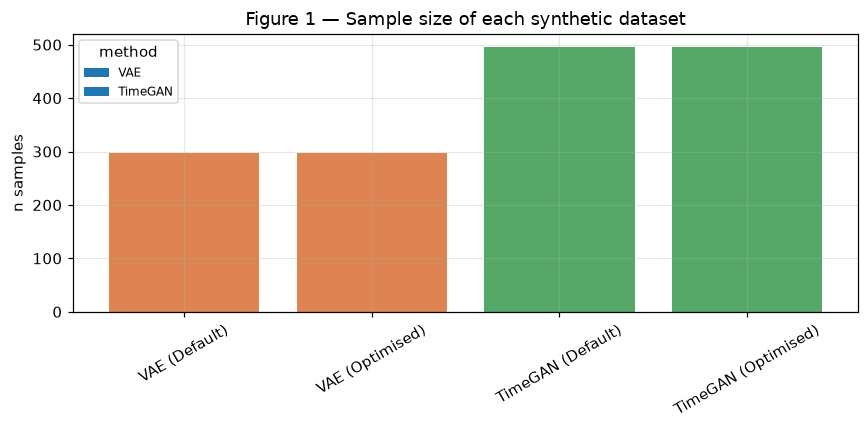

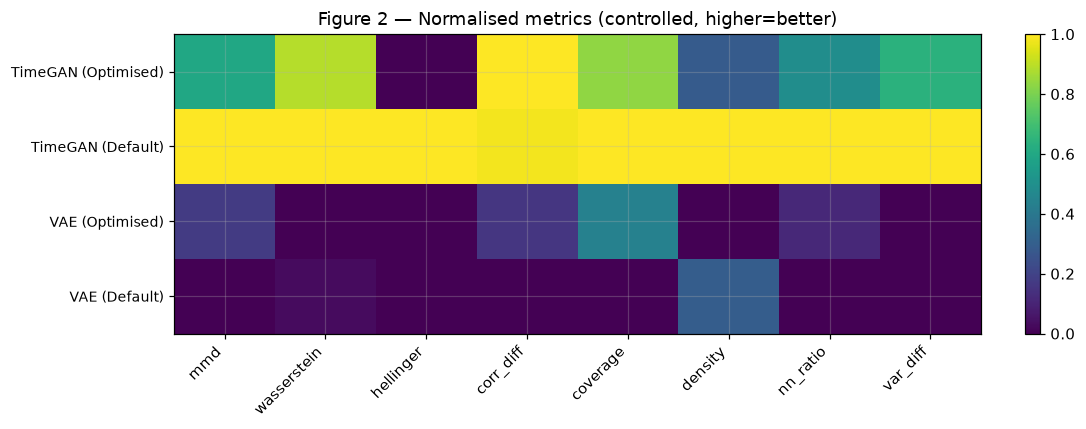

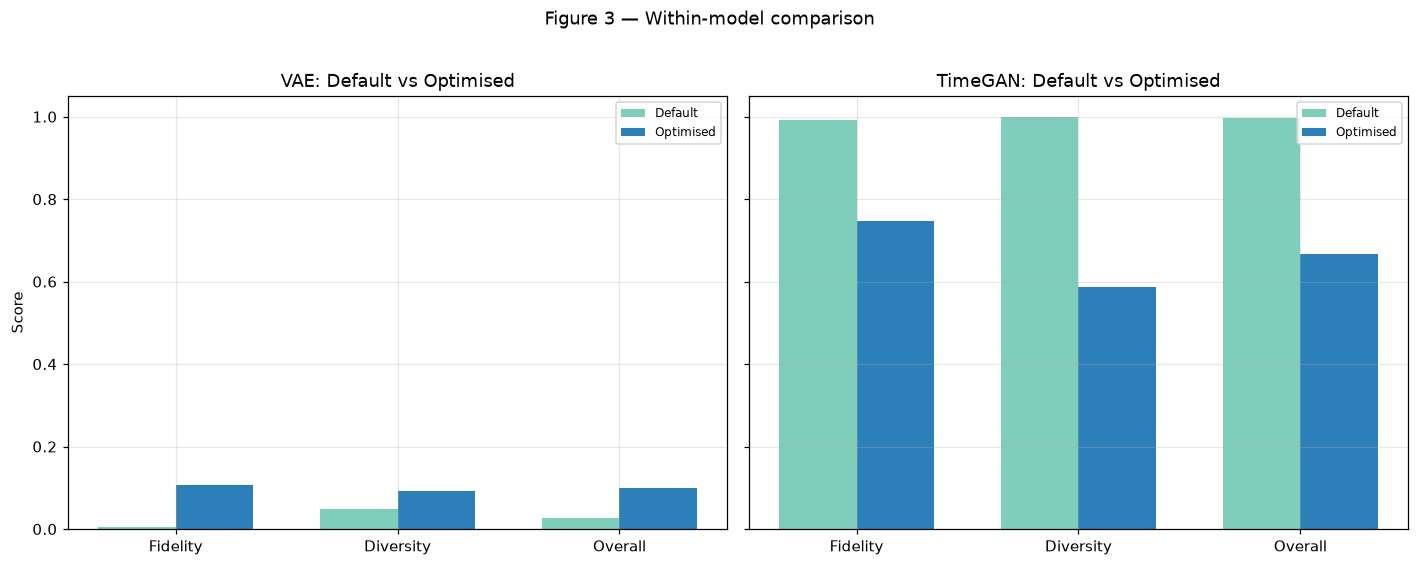

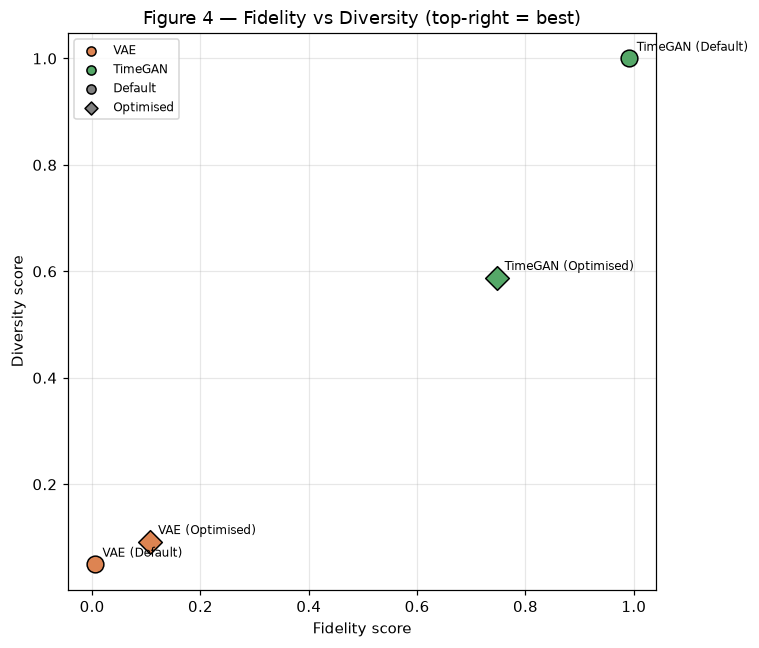

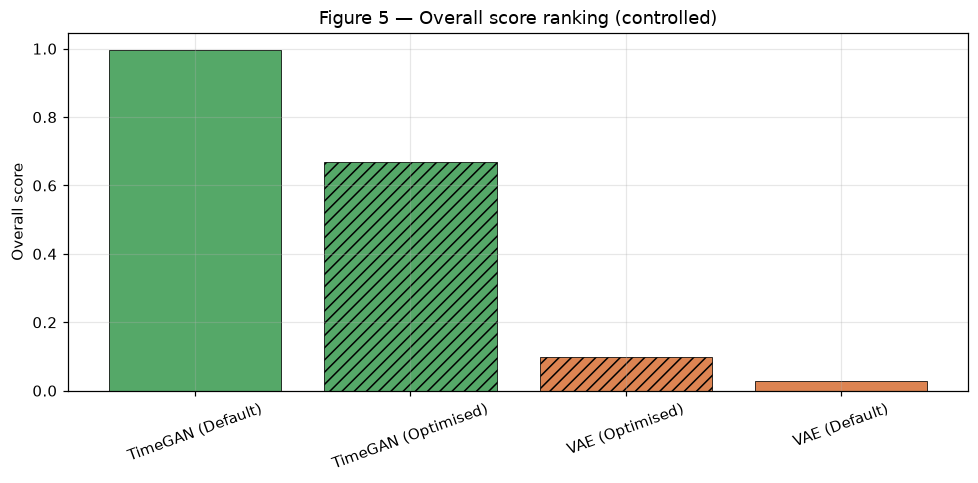

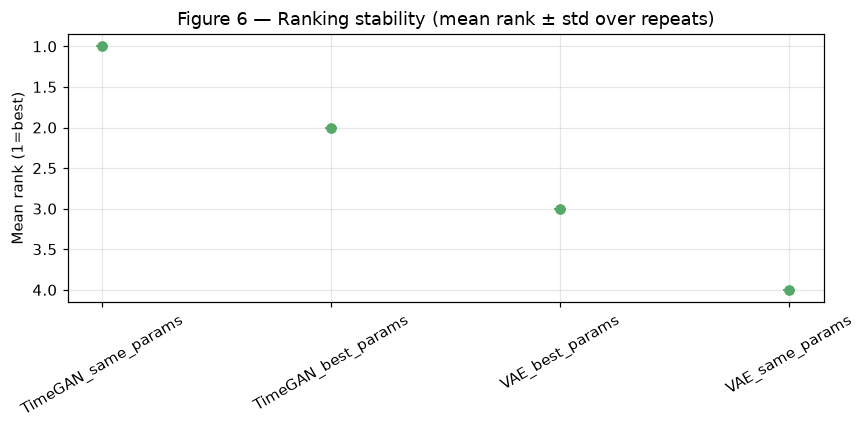

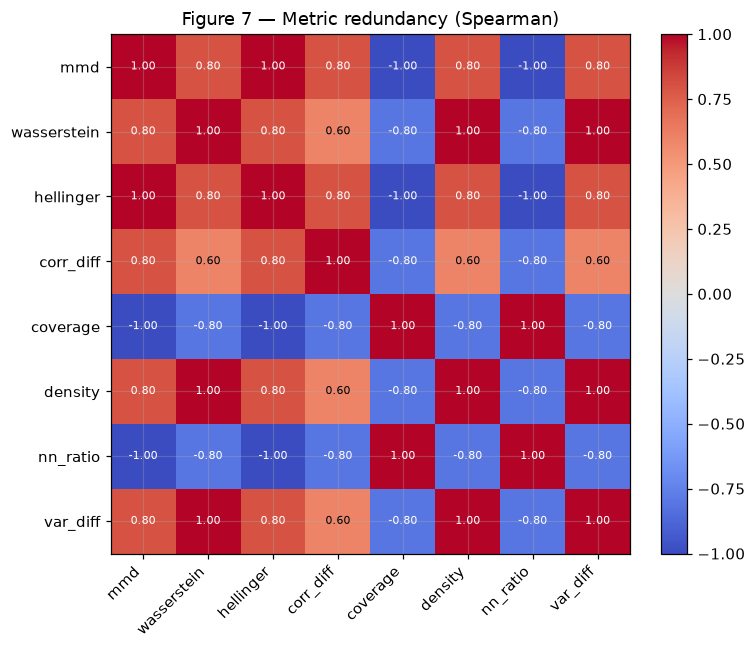

Saved 7 figures to c:\Users\mabideen\Downloads\Data_Augmentation\evaluation_and_comparison\Grid search\gridsearch_post_evaluation_output\figures


In [18]:
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130, "axes.grid": True, "grid.alpha": 0.3})
def _save(fig, fn): fig.tight_layout(); fig.savefig(FIG_DIR / fn, bbox_inches="tight"); plt.show(); plt.close(fig)
PALETTE_METHOD = {"VAE": "#DD8452", "TimeGAN": "#55A868"}
PALETTE_HP     = {"Default": "#7FCDBB", "Optimised": "#2C7FB8"}

# Fig 1 — Sample sizes
fig, ax = plt.subplots(figsize=(8, 4))
d = FULL_RAW.sort_values("n_synth")
ax.bar(d["display"], d["n_synth"], color=[PALETTE_METHOD.get(x, "#888") for x in d["method"]])
ax.set_title("Figure 1 — Sample size of each synthetic dataset"); ax.set_ylabel("n samples")
ax.tick_params(axis="x", rotation=30)
for lbl, c in PALETTE_METHOD.items(): ax.bar([], [], color=c, label=lbl)
ax.legend(title="method", fontsize=8); _save(fig, "fig1_sample_sizes.png")

# Fig 2 — Normalised metric heatmap (controlled)
fig, ax = plt.subplots(figsize=(10, 4))
H = CONTROLLED_SCORED.set_index("display")[[f"n_{m}" for m in ALL_METRICS]]
im = ax.imshow(H.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(ALL_METRICS))); ax.set_xticklabels(ALL_METRICS, rotation=45, ha="right")
ax.set_yticks(range(len(H))); ax.set_yticklabels(H.index, fontsize=9)
ax.set_title("Figure 2 — Normalised metrics (controlled, higher=better)"); fig.colorbar(im, fraction=0.03)
_save(fig, "fig2_metric_heatmap.png")

# Fig 3 — Within-model grouped bar
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for i, method in enumerate(METHODS):
    ax = axes[i]
    sub = CONTROLLED_SCORED[CONTROLLED_SCORED.method == method].sort_values("hp_label")
    x = np.arange(3); w = 0.35
    vals_d = sub[sub.hp_label == "Default"][["fidelity","diversity","overall"]].values.flatten()
    vals_o = sub[sub.hp_label == "Optimised"][["fidelity","diversity","overall"]].values.flatten()
    if len(vals_d) == 3 and len(vals_o) == 3:
        ax.bar(x - w/2, vals_d, w, label="Default", color=PALETTE_HP["Default"])
        ax.bar(x + w/2, vals_o, w, label="Optimised", color=PALETTE_HP["Optimised"])
    ax.set_xticks(x); ax.set_xticklabels(["Fidelity", "Diversity", "Overall"])
    ax.set_title(f"{method}: Default vs Optimised"); ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Score")
fig.suptitle("Figure 3 — Within-model comparison", fontsize=12, y=1.02)
_save(fig, "fig3_within_model_comparison.png")

# Fig 4 — Fidelity vs Diversity scatter (controlled)
fig, ax = plt.subplots(figsize=(7, 6))
for _, r in CONTROLLED_SCORED.iterrows():
    ax.scatter(r["fidelity"], r["diversity"], s=120,
               color=PALETTE_METHOD.get(r["method"], "#888"),
               marker="D" if r["hp_label"]=="Optimised" else "o",
               edgecolor="k", zorder=3)
    ax.annotate(r["display"], (r["fidelity"], r["diversity"]), fontsize=8,
                xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("Fidelity score"); ax.set_ylabel("Diversity score")
ax.set_title("Figure 4 — Fidelity vs Diversity (top-right = best)")
for lbl, c in PALETTE_METHOD.items(): ax.scatter([], [], color=c, edgecolor="k", label=lbl)
ax.scatter([], [], marker="o", color="grey", edgecolor="k", label="Default")
ax.scatter([], [], marker="D", color="grey", edgecolor="k", label="Optimised")
ax.legend(fontsize=8); _save(fig, "fig4_fidelity_vs_diversity.png")

# Fig 5 — Overall ranking bar (controlled)
fig, ax = plt.subplots(figsize=(9, 4.5))
d = CONTROLLED_SCORED.sort_values("overall", ascending=False)
colors = [PALETTE_METHOD.get(x, "#888") for x in d["method"]]
bars = ax.bar(d["display"], d["overall"], color=colors, edgecolor="k", linewidth=0.5)
# mark optimised with hatching
for bar, (_, row) in zip(bars, d.iterrows()):
    if row["hp_label"] == "Optimised":
        bar.set_hatch("///")
ax.set_title("Figure 5 — Overall score ranking (controlled)"); ax.set_ylabel("Overall score")
ax.tick_params(axis="x", rotation=20)
_save(fig, "fig5_overall_ranking.png")

# Fig 6 — Stability (mean rank ± std)
fig, ax = plt.subplots(figsize=(8, 4))
d = STABILITY.sort_values("mean_rank")
ax.errorbar(range(len(d)), d["mean_rank"], yerr=d["rank_std"], fmt="o", capsize=4, color="#55A868")
ax.set_xticks(range(len(d))); ax.set_xticklabels(d["name"], rotation=30)
ax.invert_yaxis(); ax.set_ylabel("Mean rank (1=best)")
ax.set_title("Figure 6 — Ranking stability (mean rank ± std over repeats)")
_save(fig, "fig6_ranking_stability.png")

# Fig 7 — Metric correlation heatmap
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(MET_CORR.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(ALL_METRICS))); ax.set_xticklabels(ALL_METRICS, rotation=45, ha="right")
ax.set_yticks(range(len(ALL_METRICS))); ax.set_yticklabels(ALL_METRICS)
for i in range(len(ALL_METRICS)):
    for j in range(len(ALL_METRICS)):
        v = MET_CORR.values[i, j]
        if np.isfinite(v): ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                                    color="white" if abs(v) > 0.6 else "black")
ax.set_title("Figure 7 — Metric redundancy (Spearman)"); fig.colorbar(im, fraction=0.046)
_save(fig, "fig7_metric_correlation.png")

print("Saved 7 figures to", FIG_DIR)

## 19. Export results

In [19]:
CONTROLLED_RAW.to_csv(RESULTS_DIR / "controlled_raw_per_repeat.csv", index=False)
CONTROLLED_SCORED.to_csv(RESULTS_DIR / "controlled_evaluation_results.csv", index=False)
FULL_SCORED.to_csv(RESULTS_DIR / "full_size_evaluation_results.csv", index=False)
MET_CORR.to_csv(RESULTS_DIR / "metric_correlation_matrix.csv")
STABILITY.to_csv(RESULTS_DIR / "ranking_stability.csv", index=False)
FINAL.to_csv(RESULTS_DIR / "gridsearch_post_evaluation_results.csv", index=False)
DISCRIM.to_csv(RESULTS_DIR / "metric_discrimination.csv", index=False)
print("Wrote CSVs to", RESULTS_DIR)
for f in sorted(RESULTS_DIR.glob("*.csv")): print("  ", f.name)

Wrote CSVs to c:\Users\mabideen\Downloads\Data_Augmentation\evaluation_and_comparison\Grid search\gridsearch_post_evaluation_output
   controlled_evaluation_results.csv
   controlled_raw_per_repeat.csv
   dataset_metadata.csv
   full_size_evaluation_results.csv
   gridsearch_post_evaluation_results.csv
   metric_correlation_matrix.csv
   metric_discrimination.csv
   ranking_stability.csv


## 20. Interpretation report

Auto-generated from computed values, answering the key questions of this grid-search evaluation.

In [20]:
def _fmt(x): return f"{x:.3f}" if np.isfinite(x) else "NaN"

lines = []
top = FINAL.iloc[0]
best_fid = CONTROLLED_SCORED.loc[CONTROLLED_SCORED["fidelity"].idxmax()]
best_div = CONTROLLED_SCORED.loc[CONTROLLED_SCORED["diversity"].idxmax()]

lines.append("=" * 78)
lines.append("GRID SEARCH POST-EVALUATION — INTERPRETATION REPORT")
lines.append("=" * 78)

lines.append(f"\nSensor configuration: {SENSOR_LABEL} (fixed)")
lines.append(f"Datasets evaluated: {len(SYNTH_LIST)} (2 methods x 2 HP settings)")

lines.append(f"\nQ1. Best overall dataset (combined quality+quantity):")
lines.append(f"    {top['dataset']} ({top['display']}) — combined {_fmt(top['combined_score'])} "
             f"[quality {_fmt(top['overall_score'])}, full_N {int(top['full_N'])}]")

lines.append(f"\nQ2. Strongest fidelity: {best_fid['display']} ({_fmt(best_fid['fidelity'])})")
lines.append(f"Q3. Strongest diversity: {best_div['display']} ({_fmt(best_div['diversity'])})")

# within-model optimisation effect
lines.append(f"\nQ4. Does optimisation help?")
for method in METHODS:
    d_score = CONTROLLED_SCORED.loc[CONTROLLED_SCORED.name == f"{method}_same_params", "overall"]
    o_score = CONTROLLED_SCORED.loc[CONTROLLED_SCORED.name == f"{method}_best_params", "overall"]
    if len(d_score) and len(o_score):
        dv, ov = float(d_score.iloc[0]), float(o_score.iloc[0])
        delta = ov - dv
        verdict = "YES ✓" if delta > 0.01 else ("marginal" if delta > 0 else "NO — default is better")
        lines.append(f"    {method}: Default={_fmt(dv)}, Optimised={_fmt(ov)}, Δ={delta:+.3f} → {verdict}")

# best method
lines.append(f"\nQ5. Best method overall:")
method_means = CONTROLLED_SCORED.groupby("method")["overall"].mean()
best_method = method_means.idxmax()
lines.append(f"    {best_method} (mean overall {_fmt(method_means[best_method])})")

lines.append(f"\n" + "-" * 78)
lines.append("RECOMMENDATION:")
for _, row in FINAL.iterrows():
    lines.append(f"  #{int(row['priority'])} {row['dataset']:25s} [{row['recommendation']}] "
                 f"combined={_fmt(row['combined_score'])}")
lines.append("-" * 78)

lines.append("\nLimitations: real N~99 with ~1137 features makes every metric approximate. "
             "Downstream utility (classifier performance on unseen real data) is the decisive test.")

report = "\n".join(lines)
print(report)
(RESULTS_DIR / "interpretation_report.txt").write_text(report)

GRID SEARCH POST-EVALUATION — INTERPRETATION REPORT

Sensor configuration: IMU+Radar (fixed)
Datasets evaluated: 4 (2 methods x 2 HP settings)

Q1. Best overall dataset (combined quality+quantity):
    TimeGAN_same_params (TimeGAN (Default)) — combined 0.997 [quality 0.996, full_N 495]

Q2. Strongest fidelity: TimeGAN (Default) (0.991)
Q3. Strongest diversity: TimeGAN (Default) (1.000)

Q4. Does optimisation help?
    VAE: Default=0.027, Optimised=0.100, Δ=+0.073 → YES ✓
    TimeGAN: Default=0.996, Optimised=0.668, Δ=-0.328 → NO — default is better

Q5. Best method overall:
    TimeGAN (mean overall 0.832)

------------------------------------------------------------------------------
RECOMMENDATION:
  #1 TimeGAN_same_params       [Highest Priority] combined=0.997
  #2 TimeGAN_best_params       [High Priority] combined=0.767
  #3 VAE_best_params           [Medium Priority] combined=0.070
  #4 VAE_same_params           [Low Priority] combined=0.019
--------------------------------------

1360

## 21. Downstream utility (optional — the decisive test)

The strongest evidence for augmentation is *does synthetic data improve fall-detection on unseen real
data?* That requires **class labels**, which the current `(N, T, F)` `.npy` inputs do **not** contain.
Set `RUN_DOWNSTREAM = True` and provide label arrays to run it.

In [21]:
RUN_DOWNSTREAM = False
# LABELS: {"real": y_real, "VAE_same_params": y, "VAE_best_params": y, "TimeGAN_same_params": y, "TimeGAN_best_params": y}
LABELS = {}

if RUN_DOWNSTREAM and LABELS:
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
    from sklearn.model_selection import StratifiedShuffleSplit

    yr = np.asarray(LABELS["real"])
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
    train_idx, test_idx = next(sss.split(X_REAL, yr))

    sc = StandardScaler().fit(X_REAL[train_idx].reshape(len(train_idx), -1))
    k = int(min(EMB_MAX_DIM, sc.mean_.shape[0], max(2, len(train_idx)-1)))
    pca = PCA(k, random_state=SEED).fit(sc.transform(X_REAL[train_idx].reshape(len(train_idx), -1)))
    emb = lambda X: pca.transform(sc.transform(X.reshape(len(X), -1)))

    Xte, yte = emb(X_REAL[test_idx]), yr[test_idx]
    results = {}
    conds = {"real_only": (emb(X_REAL[train_idx]), yr[train_idx])}
    for name, Xs in RAW_SYNTH.items():
        if name in LABELS:
            ys = np.asarray(LABELS[name])
            conds[f"real+{name}"] = (np.vstack([emb(X_REAL[train_idx]), emb(Xs)]),
                                     np.concatenate([yr[train_idx], ys]))
    for cname, (Xtr, ytr) in conds.items():
        clf = LogisticRegression(max_iter=1000).fit(Xtr, ytr); pr = clf.predict(Xte)
        results[cname] = {"f1": f1_score(yte, pr, average="macro"),
                          "precision": precision_score(yte, pr, average="macro", zero_division=0),
                          "recall": recall_score(yte, pr, average="macro", zero_division=0),
                          "accuracy": accuracy_score(yte, pr)}
    DOWNSTREAM = pd.DataFrame(results).T
    DOWNSTREAM.to_csv(RESULTS_DIR / "downstream_utility.csv")
    try: display(DOWNSTREAM)
    except NameError: print(DOWNSTREAM.to_string())
else:
    print("Downstream utility skipped: set RUN_DOWNSTREAM=True and provide LABELS.")

Downstream utility skipped: set RUN_DOWNSTREAM=True and provide LABELS.
